<a href="https://colab.research.google.com/github/aankiita/LangGraph/blob/main/LangGraph_With_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph _ChatBot_With_TOOLS


In [64]:
!pip install langgraph langsmith langchain langchain_groq langchain_community

In [65]:
from typing import Annotated
from typing_extensions import TypedDict

In [66]:
!pip install arxiv wikipedia

In [67]:
## Working With Tools

from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun

## Arxiv And Wikipedia tools
arxiv_wrapper=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=300)
arxiv_tool=ArxivQueryRun(api_wrapper=arxiv_wrapper)

api_wrapper=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=300)
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [68]:
wiki_tool.invoke("who is Sharukh Khan")

'Page: Shah Rukh Khan\nSummary: Shah Rukh Khan (pronounced [ˈʃaːɦɾʊx xäːn] ; born as Shahrukh Khan on 2 November 1965), popularly known by the initials SRK, is an Indian actor and film producer renowned for his work in Hindi cinema. Referred to in the media as the "Baadshah of Bollywood" and "King Kha'

In [69]:
arxiv_tool.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their mult'

In [70]:
tools=[wiki_tool]

In [71]:
## Langgraph Application
from langgraph.graph.message import add_messages
class State(TypedDict):
  messages:Annotated[list,add_messages]

In [72]:
from langgraph.graph import StateGraph,START,END

In [73]:
graph_builder= StateGraph(State) #state is the class

In [74]:
from langchain_groq import ChatGroq

In [75]:
from google.colab import userdata
groq_api_key=userdata.get("GROQ_API_KEY")

In [76]:
llm=ChatGroq(groq_api_key=groq_api_key,model_name="llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7c82d24d85f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7c82d24cbd10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [77]:
llm_with_tools=llm.bind_tools(tools=tools)

In [78]:
def chatbot(state:State):
  return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [79]:
from langgraph.prebuilt import ToolNode,tools_condition

In [80]:
graph_builder.add_node("chatbot",chatbot) #chatbot to tool connection.
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot") #tool to chatbot connection
graph_builder.add_edge(START,"chatbot")


In [81]:
graph=graph_builder.compile()

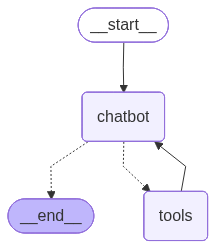

In [82]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [83]:
user_input="Hi there!, My name is John"

events=graph.stream(
     {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there!, My name is John
================================== Ai Message ==================================

It's nice to meet you, John. Is there something I can help you with or would you like to chat?


In [84]:
user_input = "what is RLHF."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]},stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is RLHF.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (yd5hhmyfz)
 Call ID: yd5hhmyfz
  Args:
    query: RLHF
================================= Tool Message =================================
Name: wikipedia

Page: Reinforcement learning from human feedback
Summary: In machine learning, reinforcement learning from human feedback (RLHF) is a technique to align an intelligent agent with human preferences. It involves training a reward model to represent preferences, which can then be used to train other mo
================================== Ai Message ==================================

RLHF stands for Reinforcement Learning from Human Feedback. It is a machine learning technique used to align an intelligent agent with human preferences. The process involves training a reward model to represent human preferences, which can then be used to train